# House Price Prediction - Exploratory Data Analysis

## Outline
- [1) Problem Statement](#1)
- [2) Dataset](#2)
- [3) Import Required Libraries](#3)

<a id="1"></a>
## 1) Problem Statement
- Predict house prices based on housing features such as area, number of bedrooms,
bathrooms, and location. 

<a id="2"></a>
## 2) Dataset
- Dataset Source - https://www.kaggle.com/datasets/nishanpokh/house-price-dataset-nepal

<a id="3"></a>
## 3) Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load the dataset

In [47]:
df=pd.read_csv("../data/raw/Nepali_house_dataset.csv")

### Show top 5 records

In [72]:
df.head()

,LOCATION,PRICE,FACING,FLOOR,BEDROOM,BATHROOM,CAR_PARKING,BIKE_PARKING,LAND_AREA,BUILDUP_AREA,...,has_drainage,has_parking,has_bathroom,has_drinking_water,has_marbel,has_power_backup,has_earthquake_resistant,has_garden,has_parquet,has_modular_kitchen
0,"Imadol, Lalitpur",29000000.0,west,3.0,5.0,4.0,1.0,2.0,4.0,NaN,...,False,True,False,True,True,False,True,False,True,True
1,"Satdobato, Lalitpur",47500000.0,west,4.5,5.0,6.0,2.0,2.0,3.0,NaN,...,False,True,True,True,False,False,True,False,True,True
2,"Imadol, Lalitpur",19900000.0,west,2.5,4.0,4.0,1.0,3.0,2.3,NaN,...,False,True,False,True,True,False,True,False,True,True
3,"Bhaisepati, Lalitpur",40000000.0,north-west,2.5,4.0,3.0,4.0,4.0,7.0,NaN,...,False,True,False,True,True,False,True,True,True,True
4,"Maharajgunj, Kathmandu",12000000.0,south,2.0,4.0,4.0,4.0,5.0,6.0,NaN,...,False,True,True,True,False,False,True,False,True,True


In [73]:
df.shape

(3228, 23)

### Exploring Data

In [5]:
for column in df.columns:
    print(df[column].value_counts())
    print("*"*20)

TITLE
 House for Sale               183
4 BHK House for Sale           52
Bungalow House for Sale        45
 House for Rent                32
4 BHK House for Rent           19
                             ... 
 Commercial house for Sale      1
 Commercial house on sale       1
 Duplex House for Sale          1
Mansion House for Sale          1
Bungalow for Sale               1
Name: count, Length: 2895, dtype: int64
********************
LOCATION
Imadol, Lalitpur               234
Bhaisepati, Lalitpur           231
Budhanilkantha, Kathmandu      192
Dhapasi, Kathmandu              74
Kapan, Kathmandu                56
                              ... 
 Lolang,  Kathmandu              1
 Thulo bharyang,  Kathmandu      1
 Grande,  Kathmandu              1
 Banglamukhi,  Kathmandu         1
 Jharuwarasi,  Lalitpur          1
Name: count, Length: 514, dtype: int64
********************
PRICE
Price on call      188
Rs. 3.5 Cr          81
Rs. 2.5 Cr          76
Rs. 2.75 Cr         65
Rs. 4.5

Column 'TITLE' can be dropped because it contains no useful information for prediction.

In [50]:
df.drop("TITLE",axis=1,inplace=True)

Target column "PRICE" having value 'Price on call' can be remove as it is unusable.

In [51]:
df = df[df["PRICE"].str.strip() != "Price on call"]

Converting "PRICE" in numbers (Nepalese Rupees).

In [52]:
import re

def clean_price(price):
    price = price.replace("Rs.", "").strip()
    
    if "Cr" in price:
        return float(price.replace("Cr","")) * 10000000
    elif "Lakh" in price:
        return float(price.replace("Lakh","")) * 100000
    else:
        return float(re.sub(r"[^\d.]", "", price))

df["PRICE"] = df["PRICE"].apply(clean_price)

Converting Land Area to Numeric.

In [53]:
df["LAND_AREA"] = df["LAND AREA"].str.extract(r"(\d+\.?\d*)").astype(float)

In [54]:
df.drop("LAND AREA",axis=1,inplace=True)

Extracting number from build area.

In [55]:
df["BUILDUP_AREA"] = df["BUILDUP AREA"].str.extract(r"(\d+\.?\d*)").astype(float)

In [56]:
df.drop("BUILDUP AREA",axis=1,inplace=True)

Extracting only number from road access and taking mean in case of range.

In [57]:
df["ROAD ACCESS"].unique()

array(['12 Feet', '10 Feet', '20 Feet', '13 Feet', '14 Feet', '16 Feet',
       '26 Feet', '25 Feet', '19 Feet', '18 Feet', '15 Feet', '24 Feet',
       '27 Feet', '30 Feet', '22 Feet', '23 Feet', '8 Feet', '11 Feet',
       '20 Meter', nan, '6 Feet', '10 Meter', '4 Feet', '40 Feet',
       '17 Feet', '13 Meter', '13-20 Feet', '12-18 Feet', '28 Feet',
       '10-12 Feet', '10-15 Feet', '12-16 Feet', '32 Feet', '12/20 Feet',
       '9 Feet', '12-14 Feet', '22  Feet', '15-26 Feet', '14-20 Feet',
       '15-20 Feet', '10-20 Feet', '12-13 Feet', '10-16 Feet',
       '14-26 Feet', '8-10 Feet', '12/13 Feet', '20  Feet', '9-12 Feet',
       '13  Feet', '10/13 Feet', '10-24 Feet', '16-22 Feet', '20-26 Feet',
       '13-15 Feet', '13-16 Feet', '12-15 Feet', '8-12 Feet',
       '15-24 Feet', '13-24 Feet', '10-26 Feet', '36 Feet', '12-20 Feet',
       '10-14 Feet', '12-26 Feet', '13-18 Feet', '15 Meter', '21 Feet',
       '0 Feet', '16-20 Feet', '10-18 Feet', '14-18 Feet', '11-14 Feet',
       '5

In [58]:
def process_road_access(x):
    if pd.isna(x):
        return np.nan
    numbers = re.findall(r'\d+\.?\d*', str(x))
    if not numbers:
        return np.nan
    elif len(numbers) == 1:
        return float(numbers[0])
    else:
        return np.mean([float(numbers[0]), float(numbers[1])])

df["ROAD_ACCESS"] = df["ROAD ACCESS"].apply(process_road_access)

In [59]:
df.drop("ROAD ACCESS",axis=1,inplace=True)

In [60]:
df["FACING"].unique()

array(['West', 'North-West', 'South', 'South-East', 'North-East', 'East',
       'South-West', 'North', nan, 'South East', 'South West', 'south',
       'North East', 'North West', 'west', 'EAST', 'West-South', 'WEST',
       'North- East', 'south west', 'NORTH', 'South-EAST', 'SOUTH',
       'East/South', 'NORTH-WEST', 'SOUTH-EAST', 'EAST-SOUTH',
       'SOUTH-WEST', 'WEST / NORTH', 'EAST-NORTH', 'EAST/WEST',
       'East-North', 'NORTH/EAST', 'South-east', 'East-South',
       'WEST-NORTH', 'WEST-SOUTH'], dtype=object)

Facing contains many duplicates. So, normalizing the text by converting everything to lowercase and using mapping to reduce categories.

In [61]:
df["FACING"] = df["FACING"].str.lower().str.strip()

In [62]:
df["FACING"] = df["FACING"].replace({
    "south east": "south-east",
    "east/south": "south-east",
    "east-south": "south-east",
    "north east": "north-east",
    "north- east": "north-east",
    "east-north": "north-east",
    "north/east": "north-east",
    "south west": "south-west",
    "west-south": "south-west",
    "north west": "north-west",
    "west / north": "north-west",
    "west-north": "north-west",
})

Extracting number from built year.

In [63]:
df["BUILT_YEAR"] = df["BUILT YEAR"].str.extract(r"(\d+)").astype(float)

In [64]:
df.drop("BUILT YEAR",axis=1,inplace=True)

Extracting car and bike parking separately.

In [65]:
df["CAR_PARKING"] = df["PARKING"].str.extract(r"(?i)(\d+)\s*car").astype(float)
df["BIKE_PARKING"] = df["PARKING"].str.extract(r"(?i)(\d+)\s*bike").astype(float)

In [66]:
df.drop("PARKING",axis=1,inplace=True)

Amenities column contains list-like strings with multiple items per property. So, converting it into a numberic column representing how many amenities each property has and also one hot encoding top 10 amenities.

In [67]:
import ast  #ast raises ValueError in case of malicious code
df["AMENITY_COUNT"] = df["AMENITIES"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)

In [68]:
df["AMENITIES"] = df["AMENITIES"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

from itertools import chain
all_amenities = list(chain.from_iterable(df["AMENITIES"]))
top_amenities = pd.Series(all_amenities).value_counts().head(10).index.tolist()

# Create binary columns for each top amenity
for amenity in top_amenities:
    df[f"has_{amenity.lower().replace(' ', '_')}"] = df["AMENITIES"].apply(lambda x: amenity in x)

In [69]:
df = df.drop("AMENITIES", axis=1)

### Checking Missing Values

In [86]:
df.isna().sum()

LOCATION                    0
PRICE                       0
FACING                      0
FLOOR                       0
BEDROOM                     0
BATHROOM                    0
LAND_AREA                   0
ROAD_ACCESS                 0
BUILT_YEAR                  0
AMENITY_COUNT               0
has_drainage                0
has_parking                 0
has_bathroom                0
has_drinking_water          0
has_marbel                  0
has_power_backup            0
has_earthquake_resistant    0
has_garden                  0
has_parquet                 0
has_modular_kitchen         0
dtype: int64

73 rows are missing in land area. Land area is important. So, filling it with median as median is better than mean for real estate.

In [77]:
df["LAND_AREA"].fillna(df["LAND_AREA"].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_21444\1963298317.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LAND_AREA"].fillna(df["LAND_AREA"].median(), inplace=True)


2543 out of 3228 buildup area is null. So, dropping the column.

In [80]:
df.drop("BUILDUP_AREA", axis=1, inplace=True)

Road access has only 8 missing values. So, filling it with median.

In [82]:
df["ROAD_ACCESS"].fillna(df["ROAD_ACCESS"].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_21444\3616333738.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ROAD_ACCESS"].fillna(df["ROAD_ACCESS"].median(), inplace=True)


Facing has 177 missing values. Filling it with mode.

In [83]:
df["FACING"].fillna(df["FACING"].mode()[0], inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_21444\771956486.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["FACING"].fillna(df["FACING"].mode()[0], inplace=True)


Filling floor, bedroom, bathroom and built year with median as they have small missing number and are important.

In [84]:
df["FLOOR"].fillna(df["FLOOR"].median(), inplace=True)
df["BEDROOM"].fillna(df["BEDROOM"].median(), inplace=True)
df["BATHROOM"].fillna(df["BATHROOM"].median(), inplace=True)
df["BUILT_YEAR"].fillna(df["BUILT_YEAR"].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_21444\494223485.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["FLOOR"].fillna(df["FLOOR"].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_21444\494223485.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

Car parking and bike parking are sparse. So, dropping them.

In [85]:
df.drop("CAR_PARKING", axis=1, inplace=True)
df.drop("BIKE_PARKING", axis=1, inplace=True)

### Checking Duplicates

In [88]:
df.duplicated().sum()

np.int64(2)

Removing the Duplicates

In [90]:
df = df.drop_duplicates()

### Checking Data types

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3226 entries, 0 to 3417
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   LOCATION                  3226 non-null   object 
 1   PRICE                     3226 non-null   float64
 2   FACING                    3226 non-null   object 
 3   FLOOR                     3226 non-null   float64
 4   BEDROOM                   3226 non-null   float64
 5   BATHROOM                  3226 non-null   float64
 6   LAND_AREA                 3226 non-null   float64
 7   ROAD_ACCESS               3226 non-null   float64
 8   BUILT_YEAR                3226 non-null   float64
 9   AMENITY_COUNT             3226 non-null   int64  
 10  has_drainage              3226 non-null   bool   
 11  has_parking               3226 non-null   bool   
 12  has_bathroom              3226 non-null   bool   
 13  has_drinking_water        3226 non-null   bool   
 14  has_marbel   

### Correlation Analysis

<Axes: >

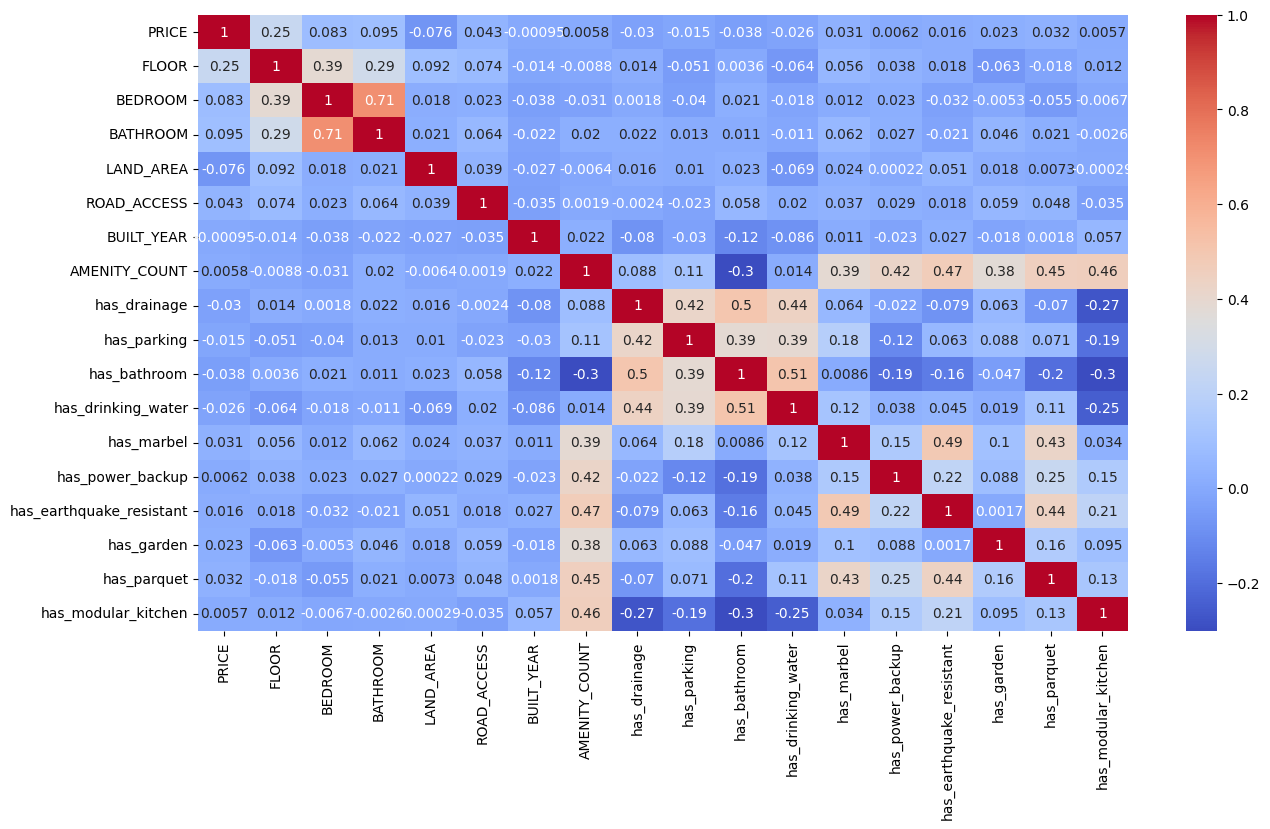

In [92]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

In [93]:
corr

,PRICE,FLOOR,BEDROOM,BATHROOM,LAND_AREA,ROAD_ACCESS,BUILT_YEAR,AMENITY_COUNT,has_drainage,has_parking,has_bathroom,has_drinking_water,has_marbel,has_power_backup,has_earthquake_resistant,has_garden,has_parquet,has_modular_kitchen
PRICE,1.000000,0.250567,0.082751,0.095050,-0.076153,0.043031,-0.000952,0.005794,-0.030455,-0.015105,-0.037522,-0.026258,0.030910,0.006196,0.015638,0.022891,0.032045,0.005730
FLOOR,0.250567,1.000000,0.385667,0.286780,0.092367,0.073597,-0.013706,-0.008820,0.014327,-0.051391,0.003550,-0.064364,0.056061,0.037792,0.017806,-0.063380,-0.018074,0.011905
BEDROOM,0.082751,0.385667,1.000000,0.708997,0.017977,0.022944,-0.038286,-0.030644,0.001818,-0.039753,0.020603,-0.018388,0.011674,0.023028,-0.031697,-0.005349,-0.055291,-0.006741
BATHROOM,0.095050,0.286780,0.708997,1.000000,0.021013,0.064169,-0.021905,0.020340,0.021673,0.012954,0.011013,-0.010847,0.062065,0.027208,-0.020864,0.046372,0.020622,-0.002603
LAND_AREA,-0.076153,0.092367,0.017977,0.021013,1.000000,0.038633,-0.027087,-0.006393,0.016190,0.009950,0.023181,-0.069294,0.023810,0.000217,0.051013,0.017632,0.007349,-0.000289
ROAD_ACCESS,0.043031,0.073597,0.022944,0.064169,0.038633,1.000000,-0.034747,0.001875,-0.002417,-0.023339,0.057965,0.020276,0.037260,0.028662,0.017588,0.059272,0.048362,-0.035461
BUILT_YEAR,-0.000952,-0.013706,-0.038286,-0.021905,-0.027087,-0.034747,1.000000,0.022197,-0.080322,-0.029798,-0.119292,-0.086007,0.010657,-0.023016,0.027368,-0.017975,0.001786,0.057298
AMENITY_COUNT,0.005794,-0.008820,-0.030644,0.020340,-0.006393,0.001875,0.022197,1.000000,0.087611,0.111112,-0.297760,0.013876,0.385333,0.421795,0.470963,0.376038,0.452786,0.459332
has_drainage,-0.030455,0.014327,0.001818,0.021673,0.016190,-0.002417,-0.080322,0.087611,1.000000,0.417066,0.504967,0.440238,0.064313,-0.021798,-0.078640,0.062770,-0.070136,-0.272202
has_parking,-0.015105,-0.051391,-0.039753,0.012954,0.009950,-0.023339,-0.029798,0.111112,0.417066,1.000000,0.387748,0.390328,0.178605,-0.116917,0.063207,0.088409,0.071051,-0.190288
